In [5]:
# git clone https://github.com/xinntao/BasicSR.git BasicSR
# cd BasicSR && pip install -e . && cd ..

# git clone https://github.com/megvii-research/NAFNet.git NAFNet_Folder
# cd NAFNet_Folder && pip install -e . 
# cd ..

# git clone https://github.com/xinntao/Real-ESRGAN.git Realesrgan_Folder
# cd Realesrgan_Folder && pip install -e . && cd ..

In [ ]:
import sys, os, importlib.util
from contextlib import contextmanager
import cv2
import time
import numpy as np
import torch
import gdown
import tempfile
import os
from PIL import Image
import matplotlib.pyplot as plt
from torch.hub import load_state_dict_from_url
from torchvision.transforms import ToTensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
load_state_dict_from_url('https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth', "/home/student/ma/pretrained_models/")

In [10]:
# weigths
gdown.download('https://drive.google.com/uc?id=14Fht1QQJ2gMlk4N1ERCRuElg8JfjrWWR', "/home/student/ma/pretrained_models/", quiet=False)
gdown.download("https://drive.google.com/uc?id=1S0PVRbyTakYY9a82kujgZLbMihfNBLfC", "/home/student/ma/pretrained_models/", quiet=False)
gdown.download('https://drive.google.com/uc?id=1SZ6bQVYTVS_AXedBEr-_mBCC-qGYHLmf', "/home/student/ma/pretrained_models/", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=14Fht1QQJ2gMlk4N1ERCRuElg8JfjrWWR
From (redirected): https://drive.google.com/uc?id=14Fht1QQJ2gMlk4N1ERCRuElg8JfjrWWR&confirm=t&uuid=b668de87-6aec-4cf2-ac3c-d6724ef2c285
To: /home/student/ma/pretrained_models/NAFNet-SIDD-width64.pth
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 464M/464M [00:19<00:00, 24.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1S0PVRbyTakYY9a82kujgZLbMihfNBLfC
From (redirected): https://drive.google.com/uc?id=1S0PVRbyTakYY9a82kujgZLbMihfNBLfC&confirm=t&uuid=7fb8eb6a-b3e4-4f69-9dcc-b0ec931c0909
To: /home/student/ma/pretrained_models/NAFNet-GoPro-width64.pth
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 272M/272M [00:06<00:00, 41.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1SZ6bQVYTVS_AXedBEr-_m

'/home/student/ma/pretrained_models/NAFSSR-L_2x.pth'

In [11]:
def import_from_repo(repo_root, module_path, function_names, prepend=True):
    # в repo_root теперь может быть либо строка, либо список строк
    roots = repo_root if isinstance(repo_root, (list, tuple)) else [repo_root]

    @contextmanager
    def adjusted_repo_context():
        orig_sys = sys.path.copy()
        orig_cwd = os.getcwd()
        if prepend:
            # вставляем все корни сверху
            for r in roots:
                sys.path.insert(0, r)
        else:
            for r in roots:
                sys.path.append(r)
        os.chdir(roots[-1])
        try:
            yield
        finally:
            sys.path = orig_sys
            os.chdir(orig_cwd)
            # очищаем модули, начинающиеся с нужного топ-level
            top = module_path.split('.')[0]
            for mod in list(sys.modules):
                if mod.startswith(top):
                    del sys.modules[mod]

    with adjusted_repo_context():
        # сброс регистра архитектур в basicsr (если есть)
        try:
            from basicsr.utils.registry import ARCH_REGISTRY
            ARCH_REGISTRY._obj_map.clear()
        except (ImportError, AttributeError):
            pass

        spec = importlib.util.spec_from_file_location(
            module_path,
            os.path.join(roots[-1], *module_path.split('.')) + ".py"
        )
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        return {name: getattr(module, name) for name in function_names}

In [ ]:
# NAFNet - deblurring
repo1_funcs = import_from_repo(
    repo_root="/home/student/ma/NAFNet_Folder",
    module_path="basicsr.models.archs.NAFNet_arch",
    function_names=["NAFNet"]
)

# NAFNet - denoising
repo2_funcs = import_from_repo(
    repo_root="/home/student/ma/NAFNet_Folder",
    module_path="basicsr.models.archs.NAFNet_arch",
    function_names=["NAFNet"]
)

# NAFNet - SR
repo3_funcs = import_from_repo(
    repo_root="/home/student/ma/NAFNet_Folder",
    module_path="basicsr.models.archs.NAFSSR_arch",
    function_names=["NAFSSR"]
)

# RRDBNet
repo4_funcs = import_from_repo(
    repo_root="/home/student/ma/BasicSR",
    module_path="basicsr.archs.rrdbnet_arch",
    function_names=["RRDBNet"]
)

# RealESRGAN
repo5_funcs = import_from_repo(
    repo_root=["/home/student/ma/BasicSR", "/home/student/ma/Realesrgan_Folder"],
    module_path="realesrgan.utils",
    function_names=["RealESRGANer"]
)

In [14]:
Deblurring = repo1_funcs["NAFNet"]
Denoising = repo2_funcs["NAFNet"]
NAFSSR = repo3_funcs["NAFSSR"]
RRDBNet = repo4_funcs["RRDBNet"]
RealESRGANer = repo5_funcs["RealESRGANer"]

In [41]:
model1 = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
upsampler = RealESRGANer(
    scale=4,
    model_path='/home/student/ma/pretrained_models/RealESRGAN_x4plus.pth',
    model=model1,
    tile=0,
    tile_pad=10,
    pre_pad=0,
    half=False,
    device=device
)

model2 = Deblurring(
    img_channel=3,
    width=64,
    middle_blk_num=1,
    enc_blk_nums=[1, 1, 1, 28],
    dec_blk_nums=[1, 1, 1, 1]
)
checkpoint = torch.load("/home/student/ma/pretrained_models/NAFNet-GoPro-width64.pth", map_location=device)
model2.load_state_dict(checkpoint["params"])
model2 = model2.to(device).eval()

model3 = Denoising(
    img_channel=3,
    width=64,
    middle_blk_num=12,
    enc_blk_nums=[2, 2, 4, 8],
    dec_blk_nums=[2, 2, 2, 2]
)
checkpoint = torch.load("/home/student/ma/pretrained_models/NAFNet-SIDD-width64.pth", map_location=device)
model3.load_state_dict(checkpoint["params"])
model3 = model3.to(device).eval()

model4 = NAFSSR(up_scale=2, width=128, num_blks=128)
checkpoint = torch.load("/home/student/ma/pretrained_models/NAFSSR-L_2x.pth", map_location=device)
model4.load_state_dict(checkpoint["params"])
model4 = model4.to(device).eval()

In [42]:
# Депиксилизация с Real-ESRGAN
def depixelate_frame(upsampler, frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    output, _ = upsampler.enhance(img, outscale=4)

    result = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)

    return result

# NAFNet Deblurring
def deblurring(model, frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_tensor = ToTensor()(Image.fromarray(img)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)

    result = output.squeeze().permute(1,2,0).cpu().numpy()
    return cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

# NAFNet - Denoising
def denoising(model, frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_tensor = ToTensor()(Image.fromarray(img)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)

    result = output.squeeze().permute(1,2,0).cpu().numpy()
    return cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

# NAFNet - SR
def super_resolution(model, frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_tensor = ToTensor()(Image.fromarray(img)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)

    result = output.squeeze().permute(1,2,0).cpu().numpy()
    return cv2.cvtColor((result * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

# Медианное усреднение кадров
def median_weightening(frames):
    return np.median(np.stack(frames), axis=0).astype(np.uint8)

# Динамическое взвешенное усреднение кадров
def dynamic_weightening(frames):
    weights = []
    for frame in frames:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
        sharpness = np.sqrt(gx**2 + gy**2).mean()
        weights.append(sharpness)

    weights = np.array(weights)
    if weights.sum() == 0:
        weights = np.ones_like(weights)
    weights /= weights.sum()

    avg_frame = np.zeros_like(frames[0], dtype=np.float32)
    for i, frame in enumerate(frames):
        avg_frame += frame.astype(np.float32) * weights[i]

    return avg_frame.astype(np.uint8)

In [ ]:
def extract_frames(video_path, target_fps=24):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps

    frames = []
    for sec in range(int(duration)):
        frame_indices = [int(sec * fps + (i * fps / target_fps)) for i in range(target_fps)]
        for fi in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
    cap.release()
    return frames[2400:2424]

def process_frames(upsampler, model2, model3, model4, frames, use_median=True, crop_region=None):
    processed = []
    for frame in frames:
        if crop_region:
            x1, y1, x2, y2 = crop_region
            frame = frame[y1:y2, x1:x2]

        deblurred = deblurring(model2, frame)
        denoised = denoising(model3, deblurred)
        processed.append(denoised)

    if use_median:
        averaged = median_weightening(processed)     # depixelated есть очень много времени
    else:                                            # динамическое взвешивание как будто дает лучше картинку
        averaged = dynamic_weightening(processed)    # внизу картинка есть, как будто там секунды неправильно разбиты и поэтому каша есть. Но, в целом, видно улучшение кадра

    # final = super_resolution(model4, averaged)     # хз как ошибку исправить с размерностями
    depixelated = depixelate_frame(upsampler, averaged)
    return depixelated

def process_video(frames, upsampler, model2, model3, model4, use_median, crop_region):
    orig_frames = process_frames(upsampler, model2, model3, model4, frames, use_median=use_median, crop_region=None)
    cropped_frames = process_frames(upsampler, model2, model3, model4, frames, use_median=use_median, crop_region=crop_region)

    return orig_frames, cropped_frames

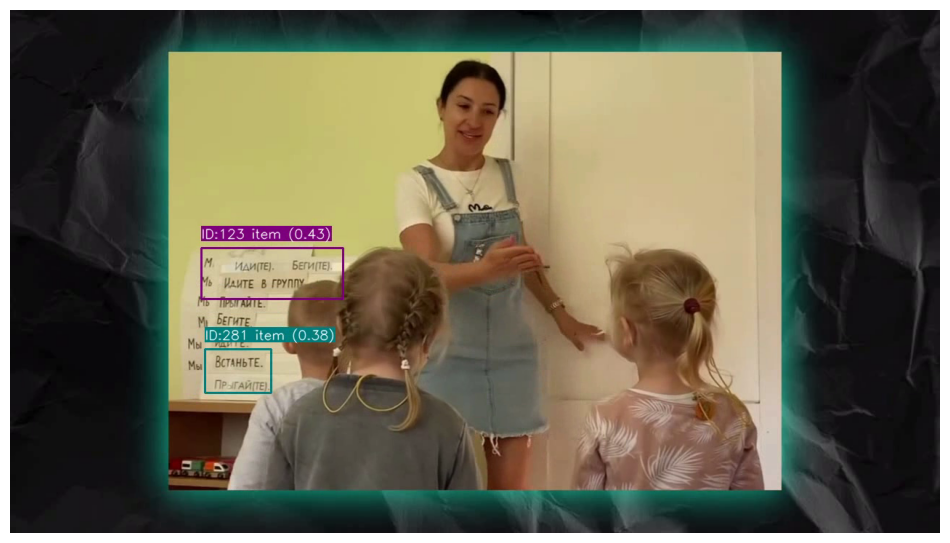

In [65]:
cap = cv2.VideoCapture("/home/student/ma/window_1_1.mp4")
if not cap.isOpened():
    raise Exception("Could not open video file")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig = plt.figure(figsize=(12, 8))
target_frame = int(fps * 100)
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame = cap.read()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    display(fig)
else:
    raise Exception("Failed to read frame")

cap.release()
plt.close()

In [66]:
video_path = "/home/student/ma/window_1_1.mp4"
frames = extract_frames(video_path)
crop_region = (200, 200, 600, 600)          # Пример области обрезки (x1,y1,x2,y2)

In [86]:
image, cropped_image = process_video(frames, upsampler, model2, model3, model4, False, crop_region)

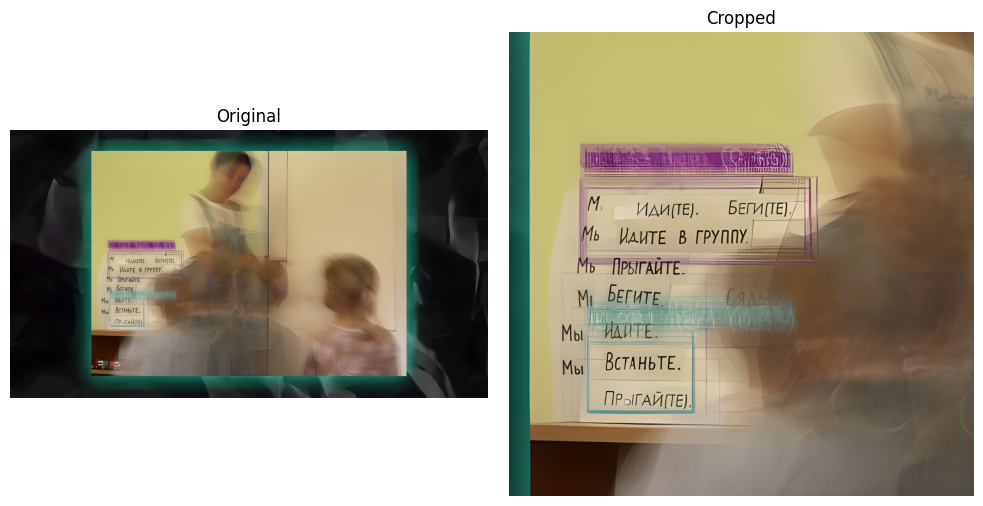

In [87]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(cropped_image)
axes[1].set_title("Cropped")
axes[1].axis('off')

plt.tight_layout()
plt.show()

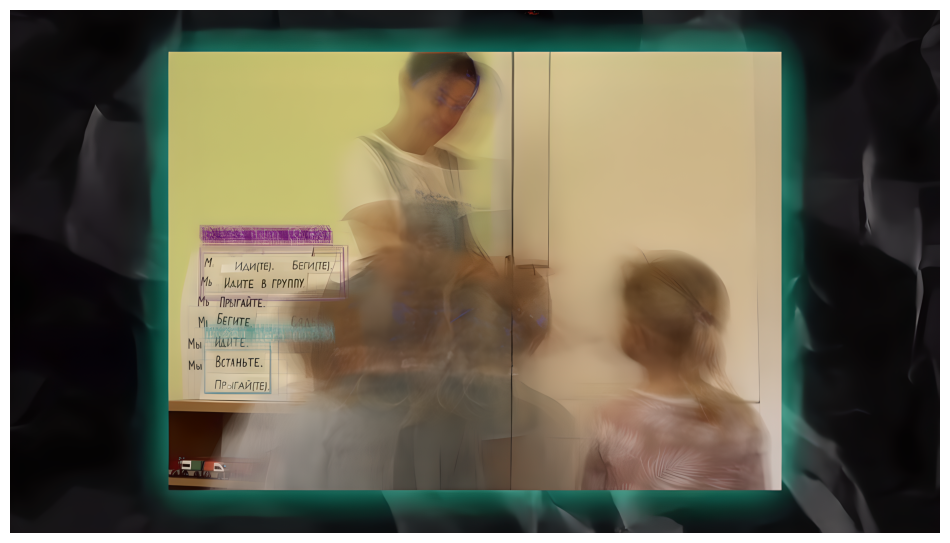

In [91]:
fig = plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')
display(fig)
plt.close()